# Field interpolation

This short tutorial demonstrates how to use `smudgy` to interpolate a particle field to arbitrary coordinates. Two concise examples are shown:

+ Interpolation of a single scalar field to a regular 2D grid of query points.
+ Interpolation of the field's gradient at the same query points.

`smudgy.grid` offers a helper function `create_grid_2d` (similar functions are available for 1D and 3D) to quickly construct equidistant coordinates. However, arbitrary coordinates can also be passed to the relevant methods.

First, let's import all the necessary packages and modules:

In [ ]:
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import numpy as np

import smudgy as sm
from smudgy.grid import create_grid_2d

In [ ]:
try:
    plt.style.use('custom')
except:
    pass
%matplotlib inline
%config InlineBackend.figure_format='retina'


## Interpolating a single scalar field

Let's generate a set of particles with (random) 2D positions, weights set to ones, and field values within a periodic box of size 1. As an example we assign each particle $j$ a field value $f_j = f(x_j,y_j)=\sin(2 \pi x_j) \cos(2 \pi y_j)$ depending on their spatial coordinates.

In [2]:
boxsize = 1.0
N = 1000
positions = np.random.uniform(0.0, boxsize, size=(N, 2))
weights = np.ones(N)

field_values = np.sin(2 * np.pi * positions[:, 0]) *\
               np.cos(2 * np.pi * positions[:, 1])

Then, we initialize a `PointCloud` instance and globally set the structure to isotropic, the kernel to a cubic spline and the number of neighbors to use in computations to 32.

In [3]:
pc = sm.PointCloud(positions,
                   weights,
                   boxsize=boxsize).\
    global_setup(kernel_name='cubic_spline',
                 structure='isotropic',
                 num_neighbors=32)

[smudgy] Initialized 2d PointCloud with 1000 particles in periodic box of size=[1. 1.]
[smudgy] Set structure globally to 'isotropic'
[smudgy] Set kernel globally to 'cubic_spline'
[smudgy] Set number of neighbors globally to 32


:::{tip}
You can disable the verbose output by either setting it during initialization `pc = PointCloud(..., verbose=False)` or overwriting it at any time with `pc.verbose = False`.
:::

Next, we compute the relevant information required for interpolation. Remembering the interpolation formula, we need the smoothing lengths $h_j$ and density $\rho_j$ of every particle,

$$
f(\mathbf{x}_i) = \sum_{j}^{n} \frac{w_j}{\rho_j} \, f_j \, W\big(\mathbf{x}_i - \mathbf{x}_j;\ h_j\big).
$$

Since we have already set the necessary parameters globally, we can simply call:

In [4]:
pc.compute_smoothing()
pc.compute_density()

[smudgy] Building kd-tree from particle positions
[smudgy] Computing smoothing lengths from 32 neighbors
[smudgy] Computing density using isotropic 'cubic_spline' kernel


Next, we construct an array of query positions with the help of `create_grid_2d` and interpolate the field values at those coordinates

In [5]:
nx, ny = 256, 256
query_positions = create_grid_2d((nx, ny), boxsize=boxsize) # shape = (nx*ny, 2)

query_values = pc.interpolate_fields(fields=field_values, query_positions=query_positions) # shape = (nx*ny, 1)

[smudgy] Interpolating fields at query positions using isotropic 'cubic_spline' kernel


Note that we could have achieved the same by first register the field as an attribute to the `PointCloud` instance and then call it by name:

In [6]:
pc.add_fields(names='field_values', values=field_values)
query_values = pc.interpolate_fields(fields='field_values', query_positions=query_positions) # shape = (nx*ny, 1)

[smudgy] Interpolating fields at query positions using isotropic 'cubic_spline' kernel


After reshaping we can plot the original particles (gray) and the field values at the query positions:

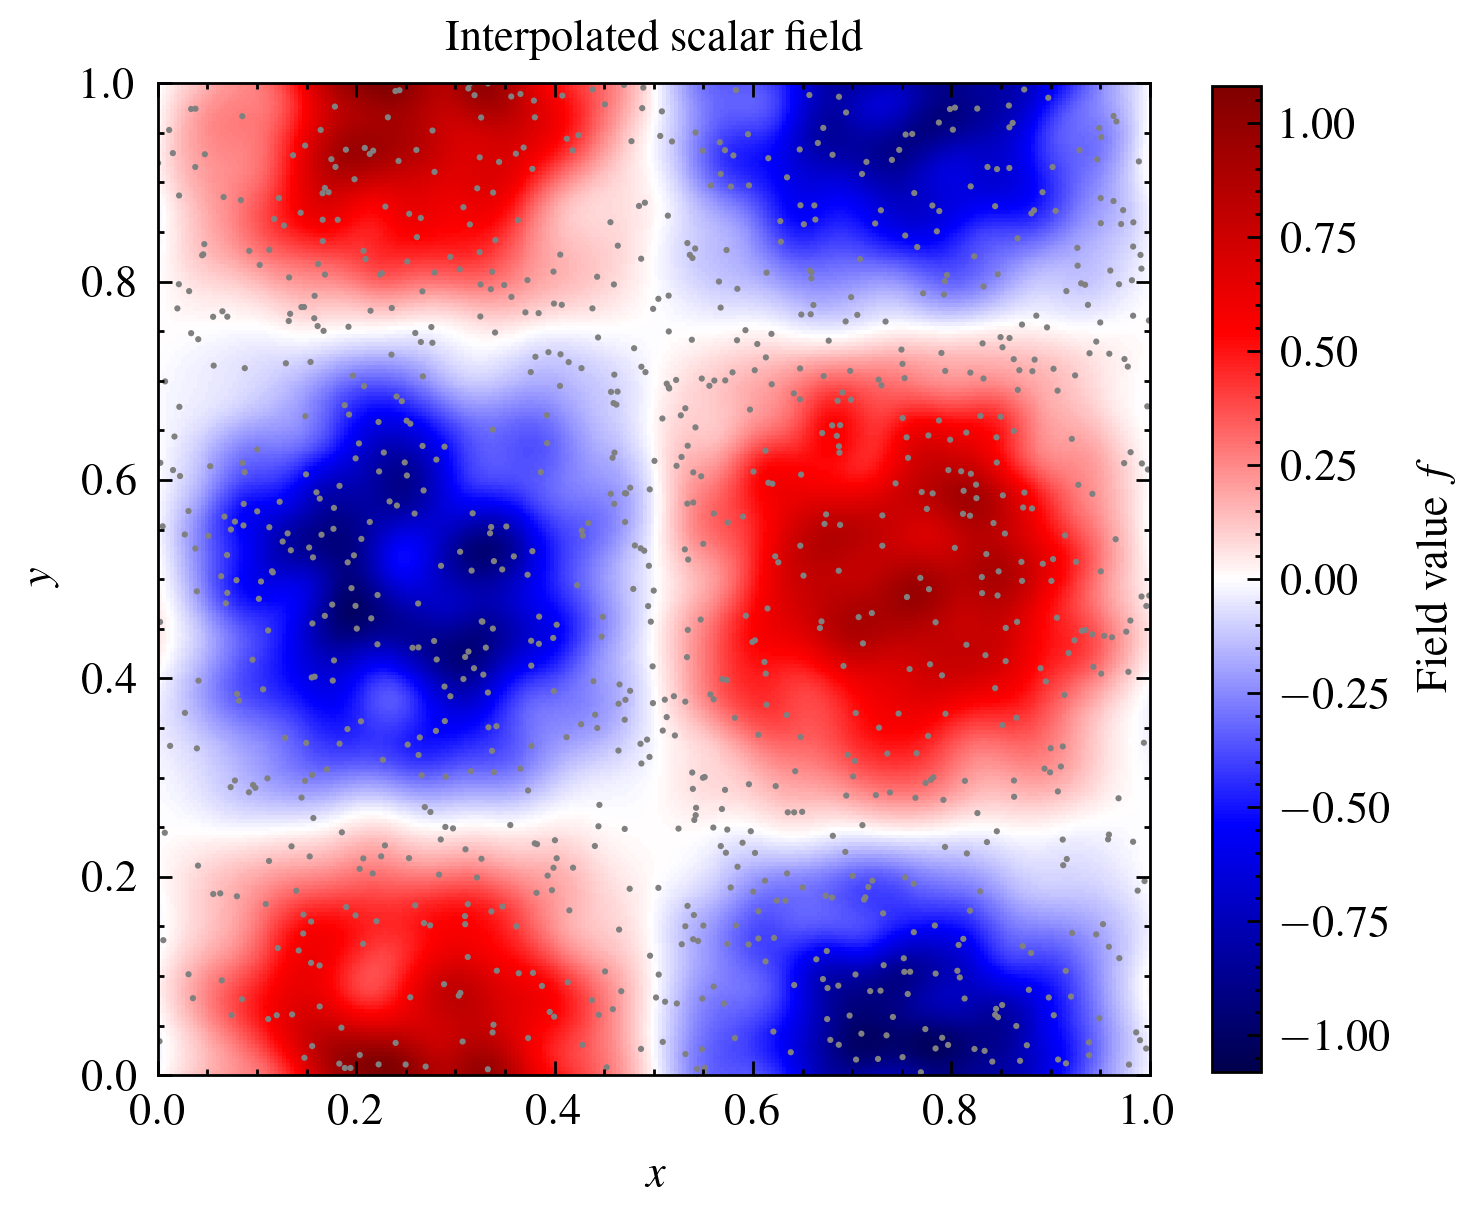

In [7]:
image = query_values.reshape((nx, ny)).T

fig, ax = plt.subplots(figsize=(4, 4))
ax.set_title('Interpolated scalar field')
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')

im = ax.imshow(image, origin='lower', extent=(0, boxsize, 0, boxsize), cmap='seismic',
               norm=colors.CenteredNorm())
ax.scatter(positions[:, 0], positions[:, 1], s=5, color='gray', edgecolors='none')
cax = plt.colorbar(im, ax=ax, shrink=0.8)
cax.set_label(r'Field value $f$')

plt.show()

## Interpolating gradients of a field

To obtain gradients at the same query points, we can either use `interpolate_fields` with the argument `compute_gradients=True` (`False` by default) or use the convenience wrapper `interpolate_gradient_fields` directly. The returned array has shape `(M, F, D)` where 
+ `M` is the number of query points, here = `nx * ny`
+ `F` is the number of fields, here = 1
+ `D` is the spatial dimension, here = 2

[smudgy] Interpolating gradients of fields at query positions using isotropic 'cubic_spline' kernel


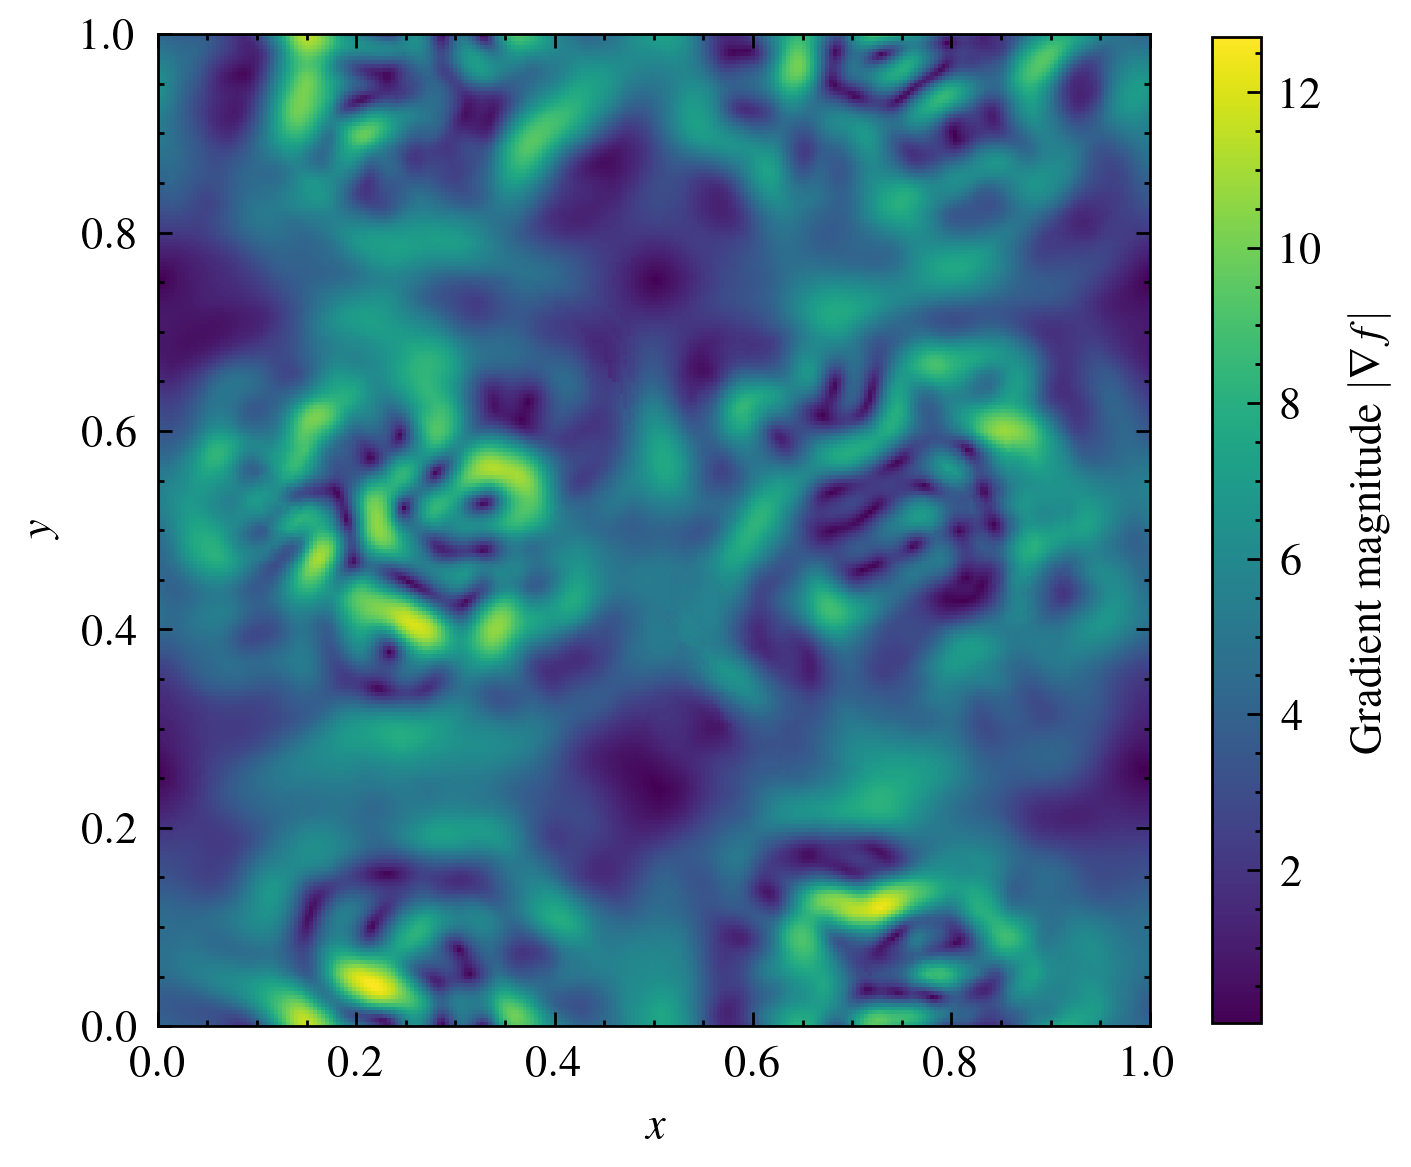

In [8]:
query_values_gradients = pc.interpolate_fields(fields=field_values,
                                               query_positions=query_positions,
                                               compute_gradients=True)  # shape = (nx*ny, 1, 2)
magnitudes = np.linalg.norm(query_values_gradients, axis=-1)
image = magnitudes.reshape((nx, ny)).T

fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(image, origin='lower', extent=(0, boxsize, 0, boxsize), cmap='viridis')
cax = plt.colorbar(im, ax=ax, shrink=0.8)
cax.set_label(r'Gradient magnitude $|\nabla f|$')

ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')

plt.show()